MovieWriter imagemagick unavailable; using Pillow instead.


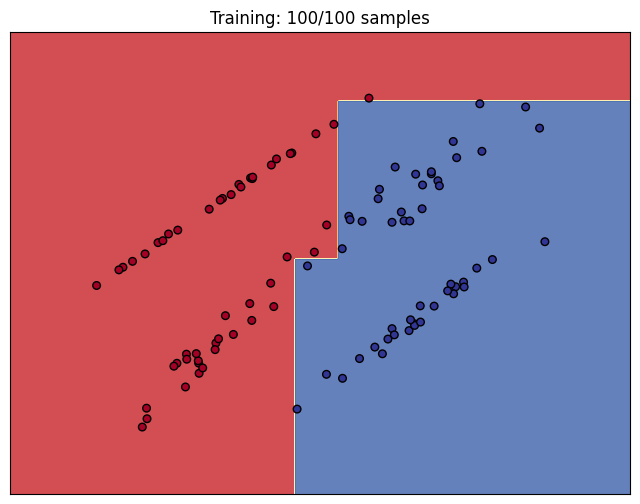

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
import matplotlib.animation as animation
# Generate a synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=42)
# Create a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Function to plot the decision boundary
def plot_decision_boundary(X, y, classifier, ax, title="Decision Tree Classifier"):
   h = .02  # Step size in the mesh
   x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
   y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
   xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
   Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
   Z = Z.reshape(xx.shape)
   ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
   ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap=plt.cm.RdYlBu)
   ax.set_xticks(())
   ax.set_yticks(())
   ax.set_title(title)
# Animation function to update the plot for each training step
def animate(i):
   ax.clear()  # Clear previous plot
   # Train the classifier step by step
   clf.fit(X[:i+1], y[:i+1])
   plot_decision_boundary(X, y, clf, ax, title=f"Training: {i+1}/{len(X)} samples")
   return ax,
# Create an animation
ani = animation.FuncAnimation(fig, animate, frames=len(X), interval=100, repeat=False)
# Save the animation as a GIF
ani.save('decision_tree_classifier.gif', writer='imagemagick', fps=10)
# Show the plot (optional)
plt.show()